# 07. Filtros de apuestas improbables

El modelo a veces detecta valor en el equipo débil de partidos muy desequilibrados (Oviedo-Barcelona, por ejemplo): la cuota implícita es del 20% pero el modelo dice 27%, así que sale EV>5%. El problema es que esas probabilidades suelen estar sobreestimadas y el edge es ficticio.

Aquí pruebo dos filtros para descartar ese tipo de apuestas:

- Filtro A — Probabilidad mínima del modelo: solo apuesto si P_modelo >= umbral (ej. 40%).
- Filtro B — Ratio modelo/mercado: solo apuesto si P_modelo no supera en exceso la implícita de la cuota (ej. ratio <= 1.5 quiere decir que el modelo no es más de un 50% más optimista que el mercado).

Mismo setup que el backtest principal: walk-forward sliding 5, 2012-2024.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt

DATA_PATH    = '../data/df_final_clean.csv'
TRAIN_WINDOW = 5
FIRST_TEST   = 2012
FEATURES = [
    'Home_Elo_Calc','Away_Elo_Calc','Elo_Diff',
    'Home_Market_Value','Away_Market_Value','Log_Value_Diff',
    'Diff_FIFA_Ova','Diff_FIFA_Mid','Diff_FIFA_Def','Diff_FIFA_Att',
    'Home_Streak_L5','Away_Streak_L5',
    'Home_H2H_L3','Away_H2H_L3',
]
ODDS_FILTER  = [('1',1.40,1.70),('1',2.00,2.50)]
import json
with open('../results/best_params.json') as _f:
    _bp = json.load(_f)
XGB_PARAMS = {**_bp, 'objective':'multi:softprob', 'num_class':3, 'eval_metric':'mlogloss',
              'random_state':42, 'verbosity':0, 'n_jobs':-1}
INIT_BK      = 1000.0
FLAT_STAKE   = 10.0
MIN_EV       = 0.05
KILL_MIN     = 15
KILL_THR     = 0.08

def build_elo(df, k=30, ha=100, start=1500):
    ratings = {}
    h_elos, a_elos = [], []
    for _, row in df.iterrows():
        h, a, ftr = row['HomeTeam'], row['AwayTeam'], row['FTR']
        rh = ratings.get(h, start); ra = ratings.get(a, start)
        h_elos.append(rh); a_elos.append(ra)
        e_h = 1.0 / (1.0 + 10**((ra - (rh + ha)) / 400.0))
        s_h, s_a = (1,0) if ftr=='H' else ((0.5,0.5) if ftr=='D' else (0,1))
        ratings[h] = rh + k*(s_h - e_h)
        ratings[a] = ra + k*(s_a - (1 - e_h))
    return h_elos, a_elos

df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['FTR'].isin(['H','D','A'])].dropna(subset=['Season']).copy()
df['Season'] = df['Season'].astype(int)
df = df.sort_values('Date').reset_index(drop=True)
df['Home_Elo_Calc'], df['Away_Elo_Calc'] = build_elo(df)
df['Elo_Diff'] = df['Home_Elo_Calc'] - df['Away_Elo_Calc']
for c in FEATURES:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)
df = df.dropna(subset=FEATURES+['Target','B365H','B365D','B365A'])
all_seasons  = sorted(df['Season'].unique())
test_seasons = [s for s in all_seasons if s >= FIRST_TEST]
print(f'Dataset: {len(df)} partidos | Test seasons: {test_seasons}')

Dataset: 5700 partidos | Test seasons: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [2]:
def run_backtest(min_ev=MIN_EV, min_model_prob=None, max_ratio=None):
    """
    Walk-forward 2012-2024 con filtros opcionales:
      min_model_prob : float|None — solo apostar si P_modelo >= umbral
      max_ratio      : float|None — solo apostar si P_modelo / (1/odds) <= max_ratio
                        (ratio 1.0 = mismo que mercado; 1.5 = modelo 50% más optimista)
    """
    all_bets, season_rows = [], []

    for test_s in test_seasons:
        prior = [s for s in all_seasons if s < test_s]
        tr_s  = prior[-TRAIN_WINDOW:]
        if not tr_s: continue
        tr = df['Season'].isin(tr_s)
        te = df['Season'] == test_s
        X_tr, y_tr = df.loc[tr, FEATURES].values, df.loc[tr,'Target'].values
        df_te = df[te].reset_index(drop=True)
        if len(X_tr) < 50 or len(df_te) == 0: continue

        model = CalibratedClassifierCV(XGBClassifier(**XGB_PARAMS), method='isotonic', cv=TimeSeriesSplit(n_splits=3))
        model.fit(X_tr, y_tr)
        proba   = model.predict_proba(df_te[FEATURES].values)
        classes = list(model.classes_)
        p_H = proba[:, classes.index(2)]
        p_D = proba[:, classes.index(1)]
        p_A = proba[:, classes.index(0)]

        bets = []; killed = False
        for i, row in df_te.iterrows():
            if killed: break
            oh, od, oa = float(row['B365H']), float(row['B365D']), float(row['B365A'])
            if oh < 1.05 or od < 1.05 or oa < 1.05: continue
            ftr = str(row['FTR'])
            for bt, p, odds, won in [('1',p_H[i],oh,ftr=='H'),
                                      ('X',p_D[i],od,ftr=='D'),
                                      ('2',p_A[i],oa,ftr=='A')]:
                ev = p * odds - 1
                if ev <= min_ev: continue
                if not any(bt==b and lo<=odds<hi for b,lo,hi in ODDS_FILTER): continue

                # Filtro A: probabilidad minima del modelo
                if min_model_prob is not None and p < min_model_prob:
                    continue

                # Filtro B: ratio modelo/mercado (no sobreestimar demasiado vs bookmaker)
                implied = 1.0 / odds
                if max_ratio is not None and implied > 0 and (p / implied) > max_ratio:
                    continue

                bets.append({'Season':test_s,'P_Model':p,'Won':won,'Odds':odds,
                             'Flat_P':FLAT_STAKE*(odds-1) if won else -FLAT_STAKE,
                             'Flat_S':FLAT_STAKE})

            if len(bets) >= KILL_MIN:
                obs = np.mean([b['Won'] for b in bets])
                exp = np.mean([b['P_Model'] for b in bets])
                if obs < exp - KILL_THR: killed = True

        if bets:
            b  = pd.DataFrame(bets)
            fr = b['Flat_P'].sum() / b['Flat_S'].sum()
            season_rows.append({'Season':test_s, 'N_Bets':len(b),
                                'Hit_Rate':round(b['Won'].mean(),3),
                                'Flat_ROI':round(fr,4)})
            all_bets.extend(bets)

    if not all_bets:
        return None, None
    ab  = pd.DataFrame(all_bets)
    res = pd.DataFrame(season_rows)
    roi = ab['Flat_P'].sum() / ab['Flat_S'].sum()
    pos = (res['Flat_ROI'] > 0).sum()
    bk  = INIT_BK + ab['Flat_P'].sum()
    bk_curve = INIT_BK + ab['Flat_P'].cumsum()
    peak     = np.maximum.accumulate(bk_curve)
    max_dd   = ((bk_curve - peak) / peak).min()
    return res, {'roi':roi, 'n_bets':len(ab), 'pos':pos, 'n_seasons':len(res),
                 'bk':bk, 'max_dd':max_dd}

print('Funcion run_backtest definida.')

Funcion run_backtest definida.


## Baseline (sin filtro adicional)

In [3]:
res_base, m_base = run_backtest()
print('=== BASELINE (sin filtro adicional) ===')
print(f'  Bets: {m_base["n_bets"]} | Flat ROI: {m_base["roi"]*100:+.2f}%'
      f' | BK final: {m_base["bk"]:.0f} EUR | Pos: {m_base["pos"]}/{m_base["n_seasons"]}'
      f' | Max DD: {m_base["max_dd"]*100:.1f}%')
print(res_base[['Season','N_Bets','Hit_Rate','Flat_ROI']].to_string(index=False))

=== BASELINE (sin filtro adicional) ===
  Bets: 344 | Flat ROI: +2.59% | BK final: 1089 EUR | Pos: 5/13 | Max DD: -22.8%
 Season  N_Bets  Hit_Rate  Flat_ROI
   2012      60     0.567    0.1618
   2013      45     0.467    0.0247
   2014      15     0.533   -0.0327
   2015      15     0.467   -0.1613
   2016      30     0.667    0.2063
   2017      65     0.600    0.1428
   2018      15     0.400   -0.1887
   2019      15     0.267   -0.5200
   2020      20     0.550   -0.0310
   2021      15     0.600   -0.0620
   2022      15     0.333   -0.4320
   2023      15     0.467   -0.0787
   2024      19     0.632    0.2821


## Filtro A — Probabilidad mínima del modelo

No apuesto si la P del modelo está por debajo del umbral. La idea es evitar las situaciones donde el modelo dice "tiene un 38% de ganar" cuando el mercado da el 25%: edge alto pero probabilidad baja, que suele venir de una probabilidad inflada.

In [4]:
prob_grid = [0.35, 0.38, 0.40, 0.42, 0.45, 0.48, 0.50]
results_a = []

print('=== FILTRO A: Probabilidad minima del modelo ===')
print(f'{"P_min":>6}  {"Bets":>5}  {"Flat ROI":>9}  {"Pos":>7}  {"Max DD":>7}  {"BK final":>9}')
print('-' * 55)

# Baseline
print(f'  None  {m_base["n_bets"]:5}  {m_base["roi"]*100:+8.2f}%  '
      f'{m_base["pos"]}/{m_base["n_seasons"]:>3}  {m_base["max_dd"]*100:+6.1f}%  {m_base["bk"]:8.0f} EUR')

for pmin in prob_grid:
    _, m = run_backtest(min_model_prob=pmin)
    if m is None:
        print(f'  {pmin:.2f}  sin apuestas')
        continue
    results_a.append({'P_min':pmin, **m})
    print(f'  {pmin:.2f}  {m["n_bets"]:5}  {m["roi"]*100:+8.2f}%  '
          f'{m["pos"]}/{m["n_seasons"]:>3}  {m["max_dd"]*100:+6.1f}%  {m["bk"]:8.0f} EUR')

df_a = pd.DataFrame(results_a)

=== FILTRO A: Probabilidad minima del modelo ===
 P_min   Bets   Flat ROI      Pos   Max DD   BK final
-------------------------------------------------------
  None    344     +2.59%  5/ 13   -22.8%      1089 EUR
  0.35    344     +2.59%  5/ 13   -22.8%      1089 EUR
  0.38    344     +2.59%  5/ 13   -22.8%      1089 EUR
  0.40    344     +2.59%  5/ 13   -22.8%      1089 EUR
  0.42    344     +2.59%  5/ 13   -22.8%      1089 EUR
  0.45    340     +2.92%  5/ 13   -21.3%      1099 EUR
  0.48    334     +1.76%  6/ 13   -21.0%      1059 EUR
  0.50    298     +1.28%  6/ 13   -19.5%      1038 EUR


## Filtro B — Ratio modelo/mercado

Limito cuánto puede el modelo sobreestimar respecto a la implícita de la cuota:

- Ratio 1.0: modelo y mercado dicen lo mismo.
- Ratio 1.3: el modelo es como mucho un 30% más optimista que el mercado.
- Ratio 1.5: el modelo puede ser un 50% más optimista (que viene a ser el umbral implícito con EV>5%).

Si el mercado da 25% y el modelo dice 45% (ratio 1.8), lo más probable es que el modelo se haya pasado.

In [5]:
ratio_grid = [1.10, 1.15, 1.20, 1.25, 1.30, 1.40, 1.50, 1.75]
results_b = []

print('=== FILTRO B: Ratio maximo modelo/mercado ===')
print(f'{"Ratio":>6}  {"Bets":>5}  {"Flat ROI":>9}  {"Pos":>7}  {"Max DD":>7}  {"BK final":>9}')
print('-' * 55)

print(f'  None  {m_base["n_bets"]:5}  {m_base["roi"]*100:+8.2f}%  '
      f'{m_base["pos"]}/{m_base["n_seasons"]:>3}  {m_base["max_dd"]*100:+6.1f}%  {m_base["bk"]:8.0f} EUR')

for ratio in ratio_grid:
    _, m = run_backtest(max_ratio=ratio)
    if m is None:
        print(f'  {ratio:.2f}  sin apuestas')
        continue
    results_b.append({'Max_ratio':ratio, **m})
    print(f'  {ratio:.2f}  {m["n_bets"]:5}  {m["roi"]*100:+8.2f}%  '
          f'{m["pos"]}/{m["n_seasons"]:>3}  {m["max_dd"]*100:+6.1f}%  {m["bk"]:8.0f} EUR')

df_b = pd.DataFrame(results_b)

=== FILTRO B: Ratio maximo modelo/mercado ===
 Ratio   Bets   Flat ROI      Pos   Max DD   BK final
-------------------------------------------------------
  None    344     +2.59%  5/ 13   -22.8%      1089 EUR
  1.10    167     +3.85%  8/ 13   -13.7%      1064 EUR
  1.15    276     +5.79%  8/ 13   -10.6%      1160 EUR
  1.20    324     +4.19%  7/ 13   -19.7%      1136 EUR
  1.25    345     +3.36%  7/ 13   -20.1%      1116 EUR
  1.30    353     +3.07%  6/ 13   -19.5%      1108 EUR
  1.40    342     +3.06%  5/ 13   -21.4%      1104 EUR
  1.50    343     +2.19%  5/ 13   -23.1%      1075 EUR
  1.75    344     +2.59%  5/ 13   -22.8%      1089 EUR


## Filtro combinado A+B

In [6]:
# Tomar los mejores valores de cada sweep para combinarlos
best_a = df_a.loc[df_a['roi'].idxmax(), 'P_min'] if len(df_a) else None
best_b = df_b.loc[df_b['roi'].idxmax(), 'Max_ratio'] if len(df_b) else None

print(f'Mejor P_min (filtro A): {best_a}')
print(f'Mejor ratio  (filtro B): {best_b}')
print()

configs = [
    ('Solo A',       {'min_model_prob': best_a}),
    ('Solo B',       {'max_ratio':      best_b}),
    ('A + B',        {'min_model_prob': best_a, 'max_ratio': best_b}),
    ('Baseline',     {}),
]

print(f'{"Config":<12}  {"Bets":>5}  {"Flat ROI":>9}  {"Pos":>7}  {"BK final":>9}')
print('-' * 50)
for name, kwargs in configs:
    _, m = run_backtest(**kwargs)
    if m is None:
        print(f'{name:<12}  sin apuestas')
        continue
    print(f'{name:<12}  {m["n_bets"]:5}  {m["roi"]*100:+8.2f}%  '
          f'{m["pos"]}/{m["n_seasons"]:>3}  {m["bk"]:8.0f} EUR')

Mejor P_min (filtro A): 0.45
Mejor ratio  (filtro B): 1.15

Config         Bets   Flat ROI      Pos   BK final
--------------------------------------------------
Solo A          340     +2.92%  5/ 13      1099 EUR
Solo B          276     +5.79%  8/ 13      1160 EUR
A + B           271     +5.24%  8/ 13      1142 EUR
Baseline        344     +2.59%  5/ 13      1089 EUR


## Visualización

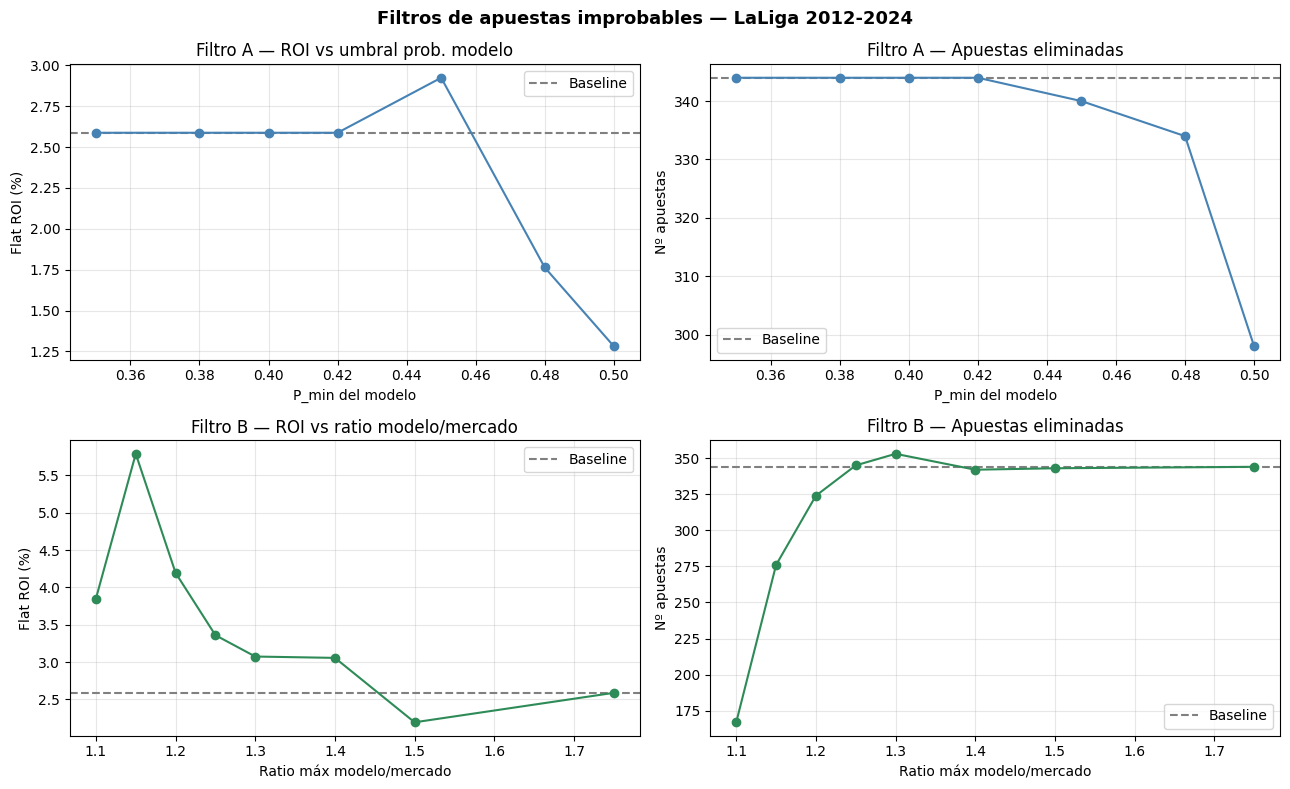

Guardado: results/filtro_improbables.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

if len(df_a):
    # Filtro A: ROI vs P_min
    axes[0,0].axhline(m_base['roi']*100, color='gray', linestyle='--', label='Baseline')
    axes[0,0].plot(df_a['P_min'], df_a['roi']*100, 'o-', color='steelblue')
    axes[0,0].set_xlabel('P_min del modelo'); axes[0,0].set_ylabel('Flat ROI (%)')
    axes[0,0].set_title('Filtro A — ROI vs umbral prob. modelo')
    axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

    axes[0,1].axhline(m_base['n_bets'], color='gray', linestyle='--', label='Baseline')
    axes[0,1].plot(df_a['P_min'], df_a['n_bets'], 'o-', color='steelblue')
    axes[0,1].set_xlabel('P_min del modelo'); axes[0,1].set_ylabel('Nº apuestas')
    axes[0,1].set_title('Filtro A — Apuestas eliminadas')
    axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

if len(df_b):
    # Filtro B: ROI vs ratio
    axes[1,0].axhline(m_base['roi']*100, color='gray', linestyle='--', label='Baseline')
    axes[1,0].plot(df_b['Max_ratio'], df_b['roi']*100, 'o-', color='seagreen')
    axes[1,0].set_xlabel('Ratio máx modelo/mercado'); axes[1,0].set_ylabel('Flat ROI (%)')
    axes[1,0].set_title('Filtro B — ROI vs ratio modelo/mercado')
    axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

    axes[1,1].axhline(m_base['n_bets'], color='gray', linestyle='--', label='Baseline')
    axes[1,1].plot(df_b['Max_ratio'], df_b['n_bets'], 'o-', color='seagreen')
    axes[1,1].set_xlabel('Ratio máx modelo/mercado'); axes[1,1].set_ylabel('Nº apuestas')
    axes[1,1].set_title('Filtro B — Apuestas eliminadas')
    axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

plt.suptitle('Filtros de apuestas improbables — LaLiga 2012-2024', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/filtro_improbables.png', dpi=120, bbox_inches='tight')
plt.show()

# Guardar resultados
if len(df_a): df_a.to_csv('../results/filtro_A_prob_sweep.csv', index=False)
if len(df_b): df_b.to_csv('../results/filtro_B_ratio_sweep.csv', index=False)
print('Guardado: results/filtro_improbables.png')

## Conclusiones

**Baseline:** 344 apuestas, Flat ROI +2.59%, 5/13 temporadas positivas, BK 1089 EUR, max DD -22.8%. Es el mismo número que sale del backtest principal del notebook 03.

**Filtro A (P_modelo ≥ umbral):** los umbrales hasta 0.42 no eliminan ninguna apuesta. Todas las que pasan el filtro de cuotas (1.40-1.70 y 2.00-2.50) ya tienen P_modelo ≥ 0.42. A partir de 0.45 hay efecto:

| P_min | Bets | Flat ROI | Pos | Max DD |
|-------|------|----------|-----|--------|
| baseline | 344 | +2.59% | 5/13 | -22.8% |
| **0.45** | **340** | **+2.92%** | **5/13** | **-21.3%** |
| 0.48 | 334 | +1.76% | 6/13 | -21.0% |
| 0.50 | 298 | +1.28% | 6/13 | -19.5% |

P_min=0.45 mejora marginalmente al baseline (+0.33 pp en yield, mismo nº de temporadas, drawdown 1.5 pp más bajo). Subir más (0.48, 0.50) recorta muestra y empeora el ROI agregado, aunque suma alguna temporada positiva. La mejora del filtro A es real pero modesta.

**Filtro B (ratio modelo/mercado ≤ umbral):** aquí está la mejora seria:

| Ratio | Bets | Flat ROI | Pos | Max DD |
|-------|------|----------|-----|--------|
| baseline | 344 | +2.59% | 5/13 | -22.8% |
| 1.10 | 167 | +3.85% | 8/13 | -13.7% |
| **1.15** | **276** | **+5.79%** | **8/13** | **-10.6%** |
| 1.20 | 324 | +4.19% | 7/13 | -19.7% |
| 1.25 | 345 | +3.36% | 7/13 | -20.1% |
| 1.30 | 353 | +3.07% | 6/13 | -19.5% |
| 1.40 | 342 | +3.06% | 5/13 | -21.4% |
| 1.50 | 343 | +2.19% | 5/13 | -23.1% |

El mejor es ratio<=1.15 con +5.79% (276 bets, 8/13 temporadas positivas, drawdown reducido a -10.6%). Es el descubrimiento principal del notebook: limitar el ratio a 1.15 mejora el yield agregado en ~3 pp, pasa de 5 a 8 temporadas positivas y baja el drawdown a la mitad. El segundo umbral más estricto (1.10) también mejora bastante (+3.85%, 8/13, dd -13.7%) pero con muestra muy reducida (167 bets). Por encima de 1.20 el filtro pierde efecto.

**Combinado A+B (P_min=0.45 + ratio≤1.15):** 271 bets, +5.24%, 8/13, BK 1142. No mejora sobre solo B (+5.79%, 276 bets), porque las apuestas que A descarta son casi un subconjunto de las que B descarta y la intersección reduce muestra sin sumar yield.

**Lectura honesta.** El filtro B con ratio<=1.15 es el descubrimiento útil. Mejora el baseline en yield (+3.2 pp), consistencia (+3 temporadas positivas) y drawdown (-12 pp). La lógica detrás es razonable: descartar las apuestas donde el modelo está mucho más optimista que el mercado, que suelen ser ruido. Pero hay que ser cauto:

1. El umbral se elige sobre los mismos datos del backtest, así que hay riesgo de selección.
2. Con 276 apuestas el IC bootstrap del ROI sigue siendo amplio.
3. La curva del filtro B no es monótona (1.10 < 1.15 > 1.20), lo que sugiere que el efecto está mezclado con ruido.

**Próximo paso recomendado:** reservar 2023-2024 como hold-out, ajustar el umbral solo con 2012-2022 y evaluar en 2023-2024 sin tocarlo. Si el filtro B con ratio<=1.15 mantiene un ROI positivo claro en ese OOS, es candidato firme para producción.